# Aprendizaje No Supervisado

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

# Cargar variables de entorno
load_dotenv()
DB_USER = os.getenv('DB_USER')
DB_PASS = os.getenv('DB_PASS')
DB_HOST = '127.0.0.1'
DB_PORT = os.getenv('DB_PORT', '3306')
DB_NAME = os.getenv('DB_NAME')

# Crear el engine de conexión
DATABASE_URL = f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

print(f"🔌 Conexión establecida con GeoLúmica DB: {DB_NAME}")

# --- CARGA COMPLETA DE TABLAS ---

# 1. Dimensiones
df_geo = pd.read_sql("SELECT * FROM dim_geografia", engine)
df_prov = pd.read_sql("SELECT * FROM dim_provincia", engine)

# 2. Tablas de Hechos (¡Ahora sí están todas!)
df_viirs = pd.read_sql("SELECT * FROM fact_viirs", engine)
df_demografia = pd.read_sql("SELECT * FROM fact_demografia", engine)
df_pib = pd.read_sql("SELECT * FROM fact_pib", engine)
df_migraciones = pd.read_sql("SELECT * FROM fact_migraciones", engine)
df_conectividad = pd.read_sql("SELECT * FROM fact_conectividad", engine)
df_consumo = pd.read_sql("SELECT * FROM fact_consumo_viviendas", engine)
df_osm = pd.read_sql("SELECT * FROM fact_osm", engine)
df_empresas = pd.read_sql("SELECT * FROM fact_empresas_transporte", engine) # ¡Añadido!

print(f"{len(df_geo)} municipios cargados en memoria.")
print(f" Dimensiones listas: Luz, Demografía, PIB, Migración, Conectividad, Consumo, OSM y Empresas.")

🔌 Conexión establecida con GeoLúmica DB: proyecto_big_data
8131 municipios cargados en memoria.
 Dimensiones listas: Luz, Demografía, PIB, Migración, Conectividad, Consumo, OSM y Empresas.


In [9]:
print("🔍 INSPECCIÓN DE COLUMNAS EN MEMORIA:")
print(f"Demografía: {list(df_demografia.columns)}")
print(f"VIIRS (Luces): {list(df_viirs.columns)}")
print(f"PIB/Renta: {list(df_pib.columns)}")
print(f"OSM (Trenes): {list(df_osm.columns)}")
print(f"Empresas: {list(df_empresas.columns)}")
print(f"Conectividad: {list(df_conectividad.columns)}")
print(f"Migraciones: {list(df_migraciones.columns)}")

🔍 INSPECCIÓN DE COLUMNAS EN MEMORIA:
Demografía: ['region_code', 'region_name', 'year', 'provincia_population', 'municipio', 'Total', 'Hombres', 'Mujeres', 'muni_id_join']
VIIRS (Luces): ['AREA_KM2', 'CNTR_CODE', 'GISCO_ID', 'LAU_ID', 'LAU_NAME', 'date', 'max', 'mean', 'min', 'stdDev', 'PROV_NAME', 'mean_prov', 'muni_id_join', 'year']
PIB/Renta: ['provincia', 'nombre_municipio', 'muni_id_join', 'anio', 'pib']
OSM (Trenes): ['PROV_NAME', 'SOG_ID', 'LAU_ID', 'LAU_NAME', 'AREA_KM2', 'POP_2023', 'stations_count', 'stations_unique', 'stations_density_km2', 'stations_with_operator_share', 'operator_count', 'stations_per_10k_pop', 'stations_within_1km_count', 'stations_within_5km_count', 'stations_in_muni_plus_1km_count', 'stations_in_muni_plus_5km_count', 'min_distance_km_to_station', 'mean_distance_km_to_station', 'accessible_count', 'accessible_share', 'category_connectivity', 'INE_PROV_CODE', 'muni_id_join']
Empresas: ['codigo', 'nombre', 'tipo', '2012', '2013', '2014', '2015', '2016', '2

In [2]:
print("\n" + "="*75)
print("📊 VERIFICACIÓN DE COBERTURA MULTI-DIMENSIONAL (DESDE MySQL)")
print("="*75)

# 1. Sacamos la lista oficial de los 8131 municipios del maestro
maestro_ids = set(df_geo['muni_key'].dropna().astype(str).str.zfill(5).unique())
total_master = len(maestro_ids)
print(f"Total de municipios en el maestro (dim_geografia): {total_master}\n")

# 2. Diccionario con todas las tablas de hechos a revisar
tablas_hechos = {
    "Demografía": df_demografia,
    "Luces (VIIRS)": df_viirs,
    "Renta/PIB": df_pib,
    "Migraciones": df_migraciones,
    "Conectividad": df_conectividad,
    "Transporte (OSM)": df_osm,
    "Empresas Logística": df_empresas,
    "Consumo Viviendas": df_consumo
}

# 3. Bucle de verificación
for nombre_tabla, df_tabla in tablas_hechos.items():
    # Extraemos los IDs únicos de esta tabla
    if 'muni_id_join' in df_tabla.columns:
        ids_tabla = set(df_tabla['muni_id_join'].dropna().astype(str).str.zfill(5).unique())
    else:
        print(f"▶ {nombre_tabla:<18} | ❌ ERROR: No tiene columna 'muni_id_join'")
        print("-" * 75)
        continue
        
    # Calculamos la intersección y la cobertura
    ids_encontrados = maestro_ids.intersection(ids_tabla)
    faltantes = maestro_ids - ids_tabla
    cobertura = (len(ids_encontrados) / total_master) * 100
    
    # Imprimimos el resultado formateado
    print(f"▶ {nombre_tabla:<18} | {len(ids_encontrados):>5} municipios vinculados | {cobertura:>6.2f}% cobertura")
    
    if cobertura == 100.0:
        print("  ✅ ¡PERFECTO! 100% de cobertura.")
    else:
        print(f"  ⚠️ Faltan {len(faltantes)} municipios.")
        # Opcional: mostrar un par de ejemplos de los que faltan cruzando con df_geo
        ejemplos_ids = list(faltantes)[:3]
        ejemplos_nombres = df_geo[df_geo['muni_key'].isin(ejemplos_ids)]['muni_display'].tolist()
        if ejemplos_nombres:
            print(f"  🔍 Ejemplos perdidos: {', '.join(ejemplos_nombres)}...")
            
    print("-" * 75)


📊 VERIFICACIÓN DE COBERTURA MULTI-DIMENSIONAL (DESDE MySQL)
Total de municipios en el maestro (dim_geografia): 8131

▶ Demografía         |  8113 municipios vinculados |  99.78% cobertura
  ⚠️ Faltan 18 municipios.
  🔍 Ejemplos perdidos: Pontes de García Rodríguez, A, Campillo, El, Torrent...
---------------------------------------------------------------------------
▶ Luces (VIIRS)      |  8131 municipios vinculados | 100.00% cobertura
  ✅ ¡PERFECTO! 100% de cobertura.
---------------------------------------------------------------------------
▶ Renta/PIB          |  8123 municipios vinculados |  99.90% cobertura
  ⚠️ Faltan 8 municipios.
  🔍 Ejemplos perdidos: Benitagla, Pesquera, Tresviso...
---------------------------------------------------------------------------
▶ Migraciones        |  8131 municipios vinculados | 100.00% cobertura
  ✅ ¡PERFECTO! 100% de cobertura.
---------------------------------------------------------------------------
▶ Conectividad       |  8131 municipio

## **Feature Engineering y PCA**

A partir de los datos del INE, calculamos:
* **`pob_absoluta_actual`**: Población total en el último año censado (escala del municipio).
* **`delta_pob_pct`**: Tasa de variación porcentual histórica. Valores negativos fuertes indican despoblación profunda.
* **`ratio_masculinidad`**: `(Hombres / Mujeres)`. En sociología rural, un valor inusualmente alto señala un núcleo en declive por la emigración de mujeres jóvenes.

In [3]:
print("⚙️ [1/5] Creando Esqueleto y calculando Deltas Demográficos...")

# 1. Esqueleto Base
df_master = df_geo[['muni_key', 'muni_display', 'prov_id_join']].copy()
df_master = df_master.rename(columns={'muni_key': 'muni_id_join'})

# 2. Demografía
max_yr_demo = df_demografia['year'].max()
min_yr_demo = df_demografia['year'].min()

demo_actual = df_demografia[df_demografia['year'] == max_yr_demo][['muni_id_join', 'Total', 'Hombres', 'Mujeres']].rename(columns={'Total': 'pob_absoluta_actual'})
# Sumamos 0.1 a mujeres para evitar división por cero en pueblos abandonados
demo_actual['ratio_masculinidad'] = demo_actual['Hombres'] / (demo_actual['Mujeres'] + 0.1) 
demo_hist = df_demografia[df_demografia['year'] == min_yr_demo][['muni_id_join', 'Total']].rename(columns={'Total': 'pob_historica'})

demo_trend = pd.merge(demo_actual, demo_hist, on='muni_id_join', how='left')
demo_trend['delta_pob_pct'] = ((demo_trend['pob_absoluta_actual'] - demo_trend['pob_historica']) / (demo_trend['pob_historica'] + 1)) * 100

df_master = pd.merge(df_master, demo_trend[['muni_id_join', 'pob_absoluta_actual', 'delta_pob_pct', 'ratio_masculinidad']], on='muni_id_join', how='left')

⚙️ [1/5] Creando Esqueleto y calculando Deltas Demográficos...


* **`luz_absoluta_actual`**: Radiancia media del último año. Define el tamaño físico/lumínico de la zona.
* **`delta_luz_pct`**: Crecimiento de la luz a lo largo de los años. Si es alto pero la población no crece, indica expansión industrial/logística.
* **`luz_volatilidad_std`**: Desviación estándar mensual. Suavizamos los picos para detectar **estacionalidad** (zonas turísticas que brillan en verano y se apagan en invierno).

In [5]:
print("⚙️ [2/5] Procesando Satélites VIIRS (Consumo y Volatilidad)...")

# Aseguramos extraer el año de la fecha
if 'year' not in df_viirs.columns:
    df_viirs['year'] = df_viirs['date'].str[:4].astype(int)

# 🚨 CORRECCIÓN: Usamos la columna 'mean' que es la que existe en tu base de datos
viirs_anual = df_viirs.groupby(['muni_id_join', 'year'])['mean'].mean().reset_index()
max_yr_viirs, min_yr_viirs = viirs_anual['year'].max(), viirs_anual['year'].min()

# Extraemos la foto actual y la histórica
viirs_actual = viirs_anual[viirs_anual['year'] == max_yr_viirs][['muni_id_join', 'mean']].rename(columns={'mean': 'luz_absoluta_actual'})
viirs_hist = viirs_anual[viirs_anual['year'] == min_yr_viirs][['muni_id_join', 'mean']].rename(columns={'mean': 'luz_historica'})

# Calculamos el Delta %
viirs_trend = pd.merge(viirs_actual, viirs_hist, on='muni_id_join', how='left')
viirs_trend['delta_luz_pct'] = ((viirs_trend['luz_absoluta_actual'] - viirs_trend['luz_historica']) / (viirs_trend['luz_historica'] + 0.01)) * 100

# Volatilidad turística/estacional (usando 'mean')
viirs_std = df_viirs.groupby('muni_id_join')['mean'].std().reset_index().rename(columns={'mean': 'luz_volatilidad_std'})

# Lo unimos a la Matriz Maestra
df_master = pd.merge(df_master, viirs_trend[['muni_id_join', 'luz_absoluta_actual', 'delta_luz_pct']], on='muni_id_join', how='left')
df_master = pd.merge(df_master, viirs_std, on='muni_id_join', how='left')

print("  ✅ VIIRS procesado e integrado con éxito.")

⚙️ [2/5] Procesando Satélites VIIRS (Consumo y Volatilidad)...
  ✅ VIIRS procesado e integrado con éxito.


Integramos los datos de la Agencia Tributaria sobre la renta disponible local.
* **`pib_absoluto_actual`**: Renta total del último año.
* **`pib_media_historica`**: Promedio de riqueza a lo largo del histórico.
* **`pib_volatilidad_std`**: Nivel de fluctuación de la economía (resiliencia frente a crisis).
* **Imputación**: A los municipios protegidos por el *Secreto Estadístico*, se les imputa automáticamente la media económica de su provincia.

In [6]:
print("⚙️ [3/5] Integrando Riqueza e Imputando Secreto Estadístico...")

col_anio_pib = 'anio' if 'anio' in df_pib.columns else 'year'
max_yr_pib = df_pib[col_anio_pib].max()

pib_actual = df_pib[df_pib[col_anio_pib] == max_yr_pib][['muni_id_join', 'pib']].rename(columns={'pib': 'pib_absoluto_actual'})
pib_stats = df_pib.groupby('muni_id_join')['pib'].agg(pib_media_historica='mean', pib_volatilidad_std='std').reset_index()

df_master = pd.merge(df_master, pib_actual, on='muni_id_join', how='left')
df_master = pd.merge(df_master, pib_stats, on='muni_id_join', how='left')

# Imputación Inteligente (Media de la provincia para los 8 nulos de secreto estadístico)
for col in ['pib_absoluto_actual', 'pib_media_historica', 'pib_volatilidad_std']:
    df_master[col] = df_master.groupby('prov_id_join')[col].transform(lambda x: x.fillna(x.median()))

⚙️ [3/5] Integrando Riqueza e Imputando Secreto Estadístico...


Combinamos variables de distintas fuentes para capturar el atractivo y la conectividad del territorio. Para normalizar los datos y evitar que el tamaño del municipio domine el modelo, usamos tasas y variaciones:

* **`delta_empresas_transporte_pct`**: Crecimiento del tejido logístico. *Cálculo: `((Empresas_Actuales - Empresas_Historicas) / Empresas_Historicas) * 100`*. Picos masivos (+400%) en zonas no metropolitanas detectan nuevos grandes nodos logísticos periféricos (el "Efecto Amazon").
* **`stations_density_km2`**: Nivel de infraestructura ferroviaria metropolitana por kilómetro cuadrado. Diferencia los núcleos urbanos densos del resto.
* **`Indice_Conectividad`**: Nivel de motorización general (vehículos).
* **`Pct_Vehiculos_Muni_vs_Prov`**: Porcentaje del parque automotor de la provincia que se concentra en este municipio específico. Detecta las "capitales de facto" en términos de movilidad.
* **`tasa_migratoria_pct`**: Tasa de presión migratoria. *Cálculo: `(Migrantes Totales / Población Total) * 100`*. Transforma el volumen bruto en una "presión de atracción" comparable, revelando si un pueblo pequeño atrae a mucha gente en proporción a su tamaño.

In [7]:
print("⚙️ [4/5] Fusionando Empresas, Transporte (OSM) y Magnetismo Migratorio...")

# 1. Empresas de Logística (Cálculo del "Efecto Amazon")
year_cols = [c for c in df_empresas.columns if c.isdigit()]
if year_cols:
    max_yr_emp, min_yr_emp = max(year_cols), min(year_cols)
    df_empresas['emp_act'] = pd.to_numeric(df_empresas[max_yr_emp], errors='coerce')
    df_empresas['emp_hist'] = pd.to_numeric(df_empresas[min_yr_emp], errors='coerce')
    
    # Variación porcentual histórica
    df_empresas['delta_empresas_transporte_pct'] = ((df_empresas['emp_act'] - df_empresas['emp_hist']) / (df_empresas['emp_hist'] + 1)) * 100
    df_master = pd.merge(df_master, df_empresas[['muni_id_join', 'emp_act', 'delta_empresas_transporte_pct']].rename(columns={'emp_act': 'empresas_transporte_actual'}), on='muni_id_join', how='left')

# 2. Conectividad y OSM (Incluyendo Pct_Vehiculos)
col_anio_con = 'Anio' if 'Anio' in df_conectividad.columns else 'year'
max_con = df_conectividad[col_anio_con].max()
con_actual = df_conectividad[df_conectividad[col_anio_con] == max_con][['muni_id_join', 'Indice_Conectividad', 'Pct_Vehiculos_Muni_vs_Prov']]
df_master = pd.merge(df_master, con_actual, on='muni_id_join', how='left')

df_master = pd.merge(df_master, df_osm[['muni_id_join', 'stations_density_km2', 'mean_distance_km_to_station']], on='muni_id_join', how='left')

# 3. Migración (Cálculo de la Tasa Migratoria)
col_anio_mig = 'anio' if 'anio' in df_migraciones.columns else 'year'
max_mig = df_migraciones[col_anio_mig].max()
mig_actual = df_migraciones[(df_migraciones[col_anio_mig] == max_mig) & (df_migraciones['nacionalidad'].str.lower() == 'total')]

df_master = pd.merge(df_master, mig_actual[['muni_id_join', 'cantidad (personas)']].rename(columns={'cantidad (personas)': 'mig_act'}), on='muni_id_join', how='left')

# Tasa = (Migrantes / Población Total) * 100
df_master['tasa_migratoria_pct'] = (df_master['mig_act'] / (df_master['pob_absoluta_actual'] + 1)) * 100
df_master = df_master.drop(columns=['mig_act']) # Borramos el dato bruto para no confundir al modelo

⚙️ [4/5] Fusionando Empresas, Transporte (OSM) y Magnetismo Migratorio...


Tratamiento matemático final de la matriz antes de inyectarla en los algoritmos:
* **Penalización de Aislamiento**: A los municipios sin datos de distancia ferroviaria en OSM se les imputa un valor extremo (`100.0` km) para que el modelo los segregue correctamente como "Aislados".
* El resto de valores residuales nulos (pueblos minúsculos sin datos de empresas) se rellenan con `0`.

In [ ]:
print("⚙️ [5/5] Limpieza de Nulos Residuales (Penalizaciones Matemáticas)...")

# Penalizamos los pueblos de montaña / aislados sin estación de OSM con 100km
df_master['mean_distance_km_to_station'] = df_master['mean_distance_km_to_station'].fillna(100.0)

# El resto de variables no mapeadas (pueblos sin registros de empresas) a cero
df_master = df_master.fillna(0)

print("\n" + "="*80)
print(f"✅ ¡MATRIZ MAESTRA LISTA PARA PCA! Dimensiones: {df_master.shape[0]} filas x {df_master.shape[1]} columnas.")
print("="*80)
display(df_master.head()) # Usamos display() que se ve mucho mejor en Jupyter que print()

🧠 INICIANDO PIPELINE DE MACHINE LEARNING (Modelo Híbrido de Dos Fases)...
   -> Separando las Grandes Urbes del mundo Rural...
   🏙️ Gigantes aislados: 153 municipios.
   🌾 Municipios rurales a analizar: 7978 municipios.

✅ Datos rurales estandarizados. Forma de la matriz: (7978, 16)


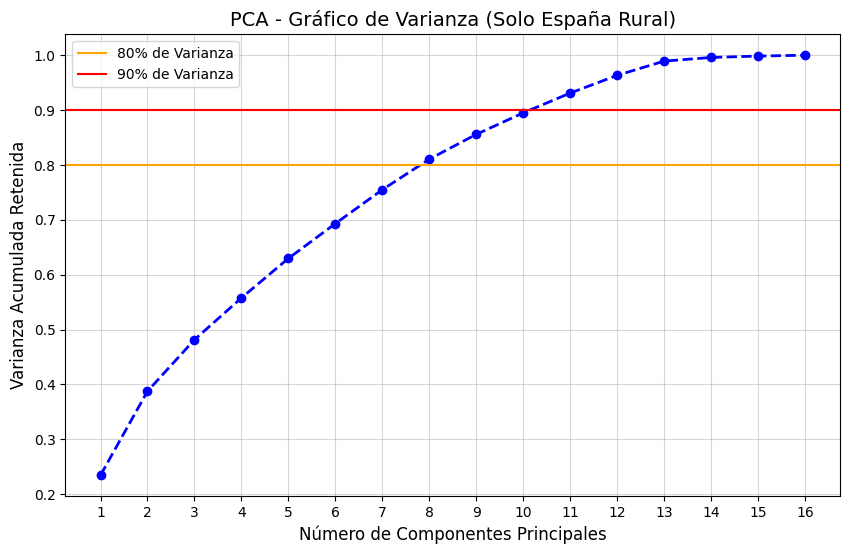


📊 Detalle de Varianza Acumulada por Componente:
Componente 1: 23.45% de la información original
Componente 2: 38.75% de la información original
Componente 3: 48.14% de la información original
Componente 4: 55.76% de la información original
Componente 5: 62.97% de la información original
Componente 6: 69.31% de la información original
Componente 7: 75.49% de la información original
Componente 8: 81.05% de la información original
Componente 9: 85.57% de la información original
Componente 10: 89.49% de la información original
Componente 11: 93.10% de la información original
Componente 12: 96.33% de la información original
Componente 13: 98.93% de la información original
Componente 14: 99.59% de la información original
Componente 15: 99.85% de la información original
Componente 16: 100.00% de la información original


In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("🧠 INICIANDO PIPELINE DE MACHINE LEARNING (Modelo Híbrido de Dos Fases)...")

# 1. Limpieza de seguridad y borrado de columnas residuales
df_master = df_master.drop_duplicates(subset=['muni_id_join']).reset_index(drop=True)
columnas_basura = ['Cluster_GeoLumina', 'Perfil_Territorial', 'Cluster_KMeans']
df_master = df_master.drop(columns=columnas_basura, errors='ignore')

# ---------------------------------------------------------
# 🚨 FASE 1: EL FILTRO METROPOLITANO (Separamos a los Gigantes)
# ---------------------------------------------------------
print("   -> Separando las Grandes Urbes del mundo Rural...")
# Filtramos ciudades de más de 50.000 habitantes (aprox. 150 municipios en España)
mascara_gigantes = df_master['pob_absoluta_actual'] > 50000

df_gigantes = df_master[mascara_gigantes].copy()
df_rural = df_master[~mascara_gigantes].copy()

print(f"   🏙️ Gigantes aislados: {len(df_gigantes)} municipios.")
print(f"   🌾 Municipios rurales a analizar: {len(df_rural)} municipios.")

# 2. Separar el "Alma" del "Cuerpo" SOLO para el mundo rural
df_ids_rural = df_rural[['muni_id_join', 'muni_display', 'prov_id_join']].reset_index(drop=True)
df_features_rural = df_rural.drop(columns=['muni_id_join', 'muni_display', 'prov_id_join']).reset_index(drop=True)

# 3. Estandarización (Escalado Z-Score clásico) SOLO al mundo rural
scaler = StandardScaler()
features_scaled_rural = scaler.fit_transform(df_features_rural)

print(f"\n✅ Datos rurales estandarizados. Forma de la matriz: {features_scaled_rural.shape}")

# 4. Calcular PCA (Para todas las componentes posibles)
pca = PCA()
pca.fit(features_scaled_rural)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

# 5. Crear el Gráfico del "Codo" (Scree Plot)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--', color='b', linewidth=2)
plt.axhline(y=0.80, color='orange', linestyle='-', label='80% de Varianza')
plt.axhline(y=0.90, color='red', linestyle='-', label='90% de Varianza')

plt.title('PCA - Gráfico de Varianza (Solo España Rural)', fontsize=14)
plt.xlabel('Número de Componentes Principales', fontsize=12)
plt.ylabel('Varianza Acumulada Retenida', fontsize=12)
plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

print("\n📊 Detalle de Varianza Acumulada por Componente:")
for i, var in enumerate(varianza_acumulada):
    print(f"Componente {i+1}: {var*100:.2f}% de la información original")

#### Extracción de Componentes y Mapa de Calor (Loadings)

Tras analizar la varianza explicada, determinamos que con **10 Componentes Principales** retenemos casi el **89%** de la información original, reduciendo el ruido pero manteniendo la esencia matemática de las 16 variables originales.

A continuación, extraemos los **Pesos (Loadings)**. Los Loadings nos indican cuánto contribuye cada variable original a cada nuevo Componente Principal. 
* Un valor cercano a `1` (rojo oscuro) o `-1` (azul oscuro) indica una correlación fortísima.
* Un valor cercano a `0` (blanco) indica que esa variable no tiene peso en ese componente.

In [52]:
import seaborn as sns

print("⚙️ [1/2] Aplicando PCA Definitivo a la España Rural (10 Componentes)...")

# 1. Ajustamos el PCA final a 10 componentes
pca_final = PCA(n_components=10, random_state=42)
matriz_pca_rural = pca_final.fit_transform(features_scaled_rural)

print(f"✅ Matriz reducida lista. Nueva forma: {matriz_pca_rural.shape}")

# 2. Generamos el dataset para el K-Means
nombres_pc = [f'PC{i+1}' for i in range(10)]
df_pca_rural = pd.DataFrame(matriz_pca_rural, columns=nombres_pc)
df_clustering_rural = pd.concat([df_ids_rural, df_pca_rural], axis=1)

print("🚀 LISTOS PARA K-MEANS: Dataset 'df_clustering_rural' generado con éxito.")

⚙️ [1/2] Aplicando PCA Definitivo a la España Rural (10 Componentes)...
✅ Matriz reducida lista. Nueva forma: (7978, 10)
🚀 LISTOS PARA K-MEANS: Dataset 'df_clustering_rural' generado con éxito.


⚙️ Evaluando el K óptimo SOLO para la España Rural...


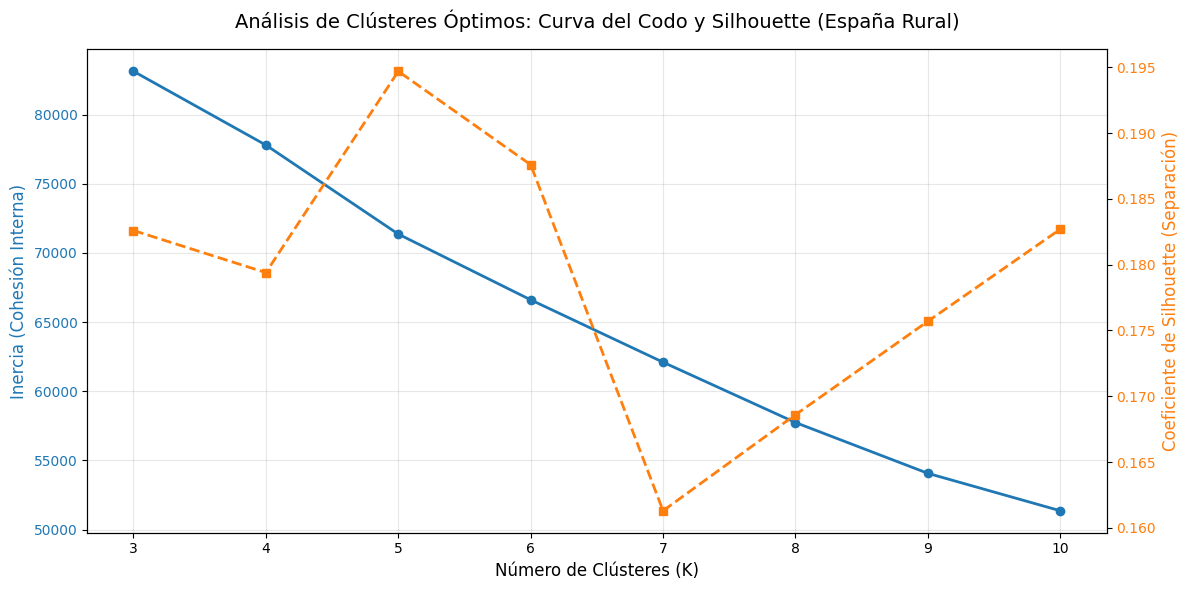


📊 TABLA DE MÉTRICAS MATEMÁTICAS POR 'K' (ESPAÑA RURAL):


,K,Inercia,Descenso_Inercia,Silhouette
0,3,83122.52,0.00,0.1826
1,4,77792.58,5329.94,0.1794
2,5,71358.31,6434.27,0.1947
3,6,66607.08,4751.23,0.1876
4,7,62098.81,4508.28,0.1613
5,8,57740.65,4358.15,0.1686
6,9,54069.26,3671.40,0.1757
7,10,51365.46,2703.80,0.1827


In [54]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

print("⚙️ Evaluando el K óptimo SOLO para la España Rural...")

# 1. Aislamos las 10 columnas numéricas del PCA RURAL (quitamos los textos)
# 🚨 CAMBIO CLAVE: Usamos df_clustering_rural
X_clustering_rural = df_clustering_rural.drop(columns=['muni_id_join', 'muni_display', 'prov_id_join'])

# 2. Variables para guardar métricas
resultados = []
rango_k = range(3, 11)

# 3. Bucle de entrenamiento
for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # 🚨 CAMBIO CLAVE: Entrenamos sobre X_clustering_rural
    etiquetas_temp = kmeans_temp.fit_predict(X_clustering_rural)
    
    inercia = kmeans_temp.inertia_
    silhouette = silhouette_score(X_clustering_rural, etiquetas_temp)
    
    resultados.append({
        'K': k,
        'Inercia': inercia,
        'Silhouette': silhouette
    })

# 4. Convertir a DataFrame y calcular el Descenso (Delta Inercia)
df_metricas = pd.DataFrame(resultados)
df_metricas['Descenso_Inercia'] = df_metricas['Inercia'].shift(1) - df_metricas['Inercia']
df_metricas['Descenso_Inercia'] = df_metricas['Descenso_Inercia'].fillna(0)
df_metricas = df_metricas[['K', 'Inercia', 'Descenso_Inercia', 'Silhouette']]

# Redondear para que la tabla se vea limpia
df_metricas['Inercia'] = df_metricas['Inercia'].round(2)
df_metricas['Descenso_Inercia'] = df_metricas['Descenso_Inercia'].round(2)
df_metricas['Silhouette'] = df_metricas['Silhouette'].round(4)

# 5. Creación del Panel Gráfico Dual
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Número de Clústeres (K)', fontsize=12)
ax1.set_ylabel('Inercia (Cohesión Interna)', color=color, fontsize=12)
ax1.plot(df_metricas['K'], df_metricas['Inercia'], marker='o', color=color, linewidth=2, label='Inercia (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Coeficiente de Silhouette (Separación)', color=color, fontsize=12)
ax2.plot(df_metricas['K'], df_metricas['Silhouette'], marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Análisis de Clústeres Óptimos: Curva del Codo y Silhouette (España Rural)', fontsize=14, pad=15)
fig.tight_layout()
plt.show()

# 6. Mostrar la Tabla de Métricas Puras
print("\n📊 TABLA DE MÉTRICAS MATEMÁTICAS POR 'K' (ESPAÑA RURAL):")
display(df_metricas)

## Modelos

In [53]:
from sklearn.cluster import KMeans

print("⚙️ [1/2] Entrenando K-Means SOLO en municipios rurales (K=6)...")

# 1. Entrenamos el K-Means con las variables del PCA
X_clustering_rural = df_clustering_rural.drop(columns=['muni_id_join', 'muni_display', 'prov_id_join'])
kmeans_rural = KMeans(n_clusters=6, random_state=42, n_init=20)
etiquetas_rurales = kmeans_rural.fit_predict(X_clustering_rural)

# Les ponemos un prefijo para saber que son los rurales
df_rural['Perfil_Territorial'] = ['Clúster Rural ' + str(c) for c in etiquetas_rurales]

# 2. Etiquetamos a los gigantes "a mano"
print("⚙️ [2/2] Reintegrando a las Grandes Urbes en el maestro...")
df_gigantes['Perfil_Territorial'] = '0 - Grandes Urbes y Motores Regionales'

# 3. Volvemos a unir a toda España en un solo DataFrame
df_master_final = pd.concat([df_gigantes, df_rural]).reset_index(drop=True)

# 4. Calculamos los perfiles medianos de las 7 zonas resultantes
columnas_perfil = [
    'pob_absoluta_actual', 'delta_pob_pct', 'delta_luz_pct', 
    'pib_media_historica', 'delta_empresas_transporte_pct', 
    'mean_distance_km_to_station', 'ratio_masculinidad'
]

perfiles_clusters = df_master_final.groupby('Perfil_Territorial')[columnas_perfil].median().round(2)
perfiles_clusters['Total_Municipios'] = df_master_final['Perfil_Territorial'].value_counts()

cols = ['Total_Municipios'] + columnas_perfil
perfiles_clusters = perfiles_clusters[cols]

print("\n" + "="*100)
print("📊 RADIOGRAFÍA HÍBRIDA DE LAS 7 ESPAÑAS (1 Urbe + 6 Rurales)")
print("="*100)
display(perfiles_clusters)

# Actualizamos tu df_master original para que el mapa lo encuentre
df_master = df_master_final.copy()

⚙️ [1/2] Entrenando K-Means SOLO en municipios rurales (K=6)...
⚙️ [2/2] Reintegrando a las Grandes Urbes en el maestro...

📊 RADIOGRAFÍA HÍBRIDA DE LAS 7 ESPAÑAS (1 Urbe + 6 Rurales)


,Total_Municipios,pob_absoluta_actual,delta_pob_pct,delta_luz_pct,pib_media_historica,delta_empresas_transporte_pct,mean_distance_km_to_station,ratio_masculinidad
Perfil_Territorial,,,,,,,,
0 - Grandes Urbes y Motores Regionales,153,92237.0,24.37,37.45,12658.22,-12.46,0.00,0.95
Clúster Rural 0,1036,4440.5,72.17,47.84,12824.72,-6.39,0.00,1.02
Clúster Rural 1,3601,706.0,-19.91,163.93,10509.44,0.00,0.00,1.06
Clúster Rural 2,110,19538.5,42.94,52.42,12814.94,-15.49,0.00,0.96
Clúster Rural 3,348,22218.5,25.68,54.94,10677.28,-12.90,0.00,0.98
Clúster Rural 4,34,1162.5,42.42,77.86,11876.94,3450.00,0.00,1.04
Clúster Rural 5,2849,117.0,-27.78,246.64,14629.00,0.00,11.53,1.26


🗺️ GENERANDO MAPA CARTOGRÁFICO DEFINITIVO DE GEOLÚMICA...
Cargando geometrías desde GeoJSON...
Pintando perfiles territoriales...


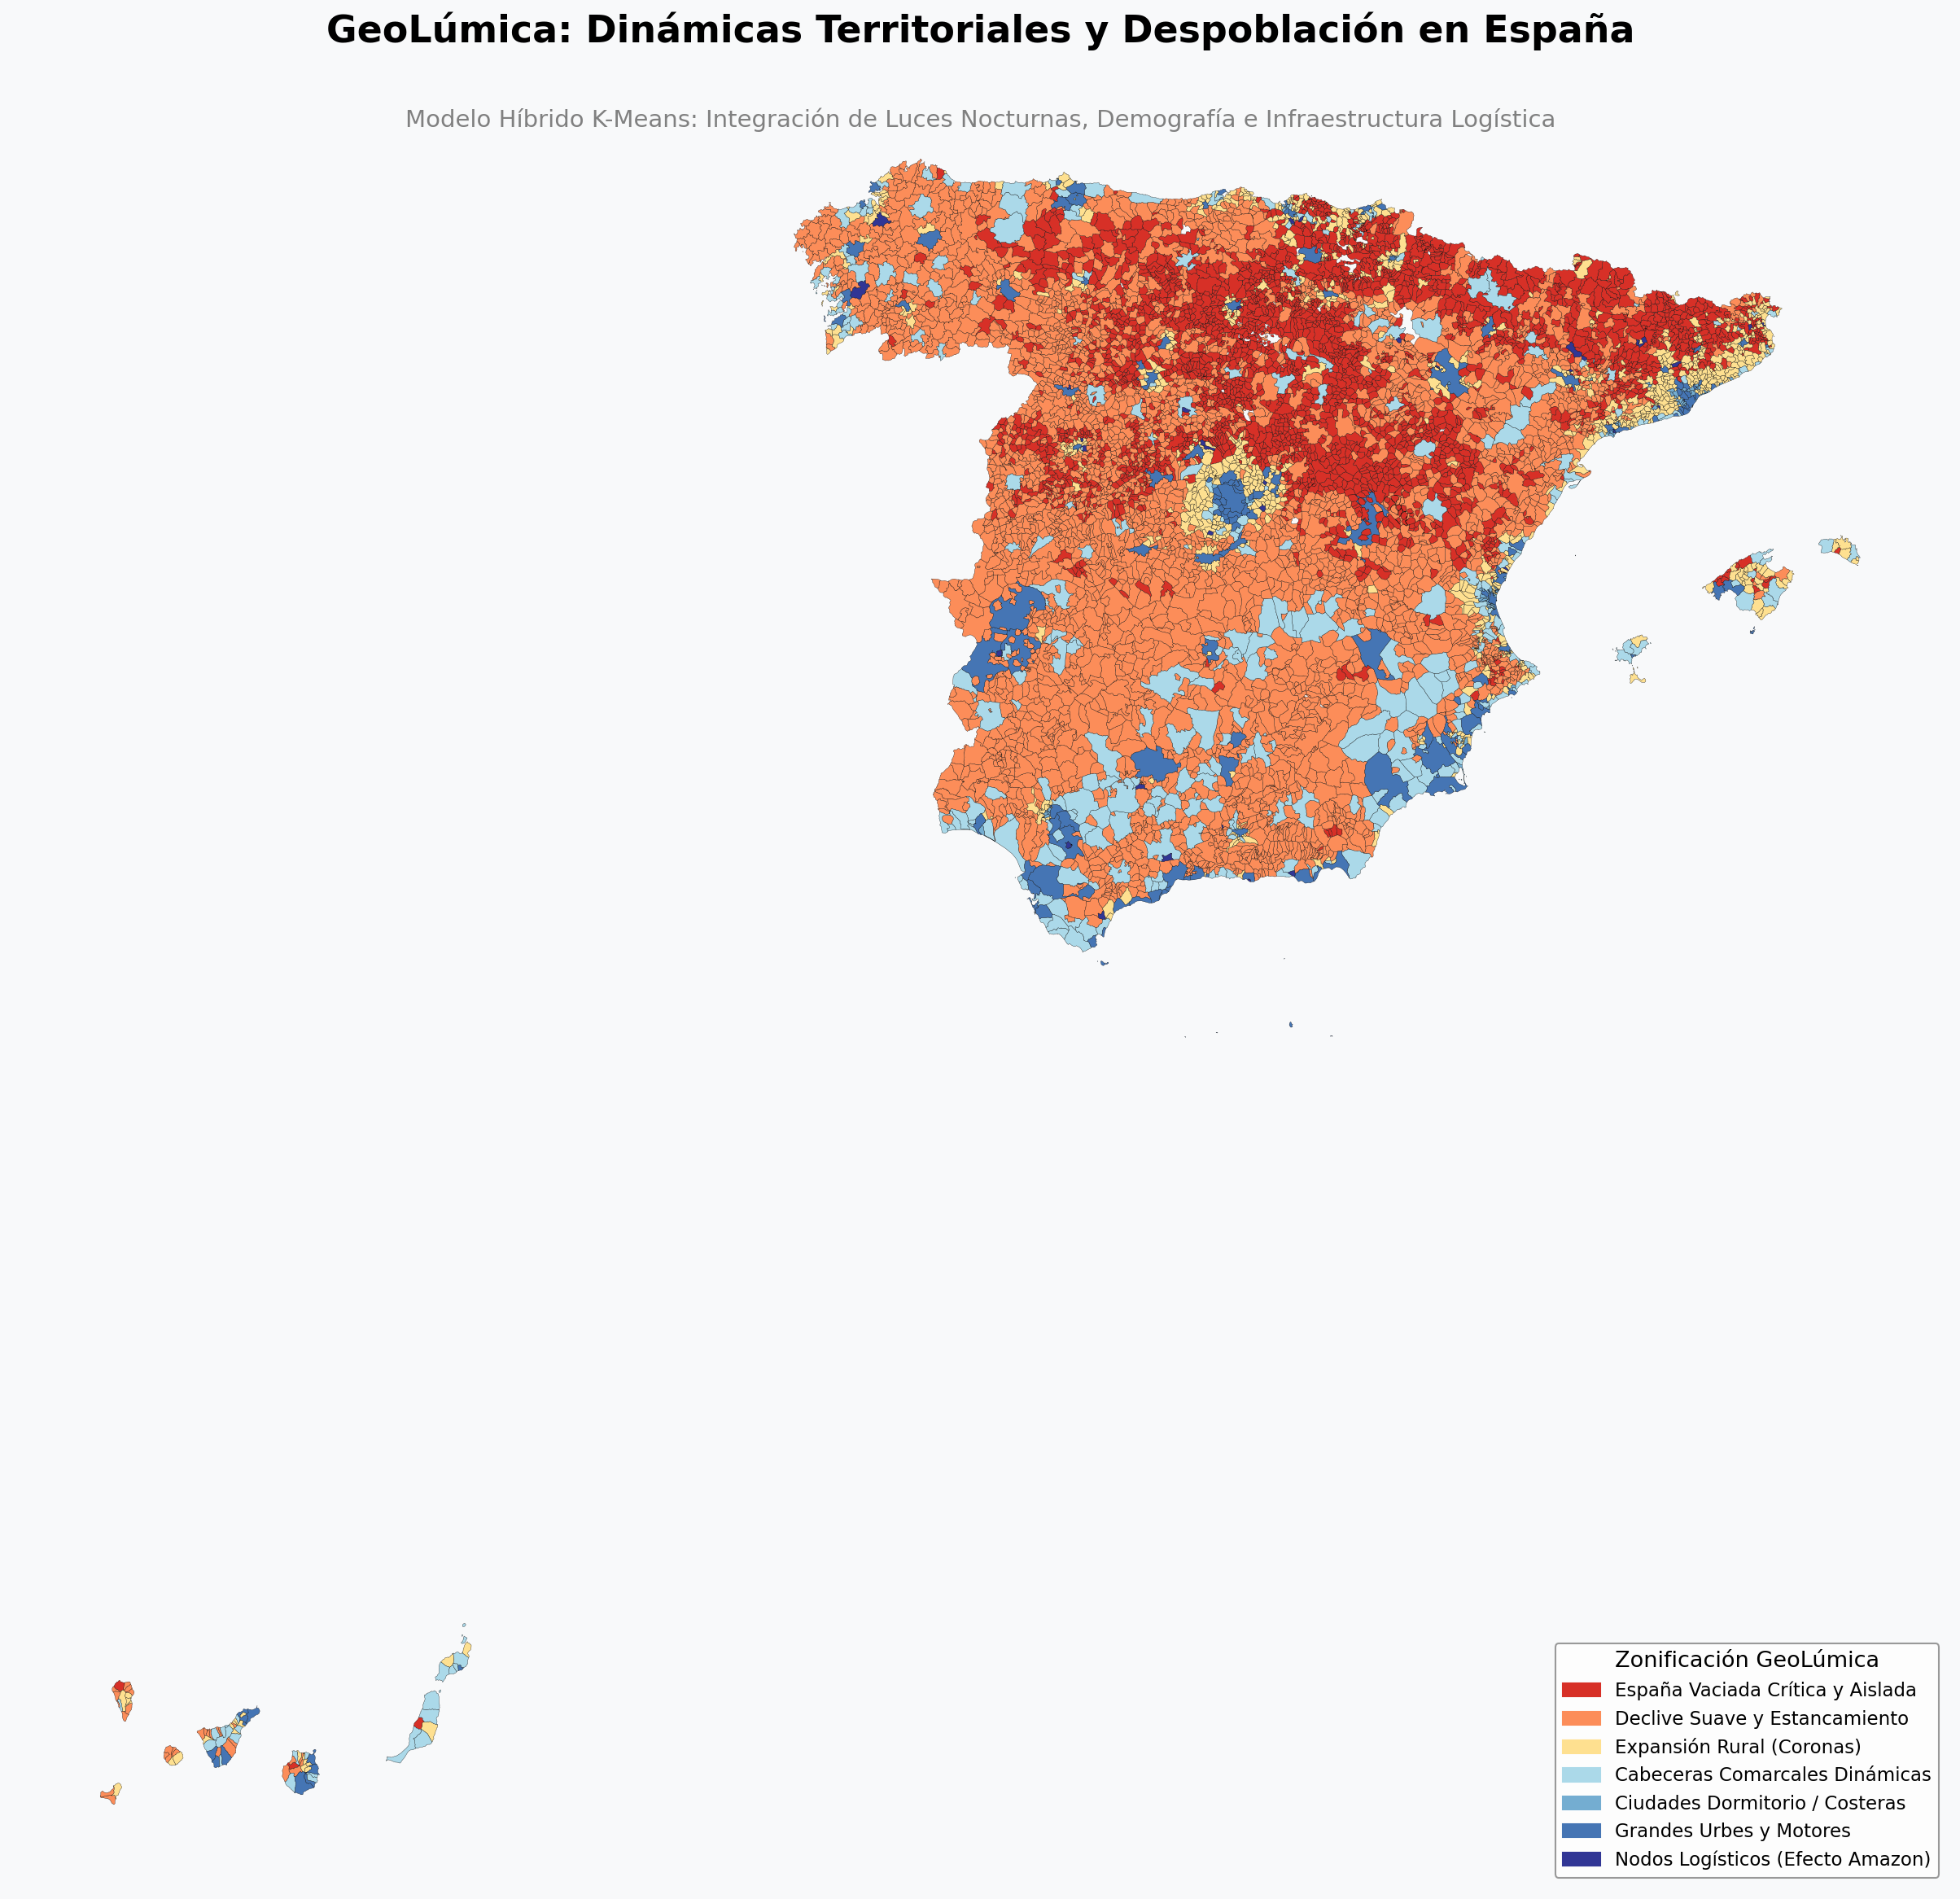

In [56]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import geopandas as gpd

print("🗺️ GENERANDO MAPA CARTOGRÁFICO DEFINITIVO DE GEOLÚMICA...")

# 1. Bautizamos los perfiles técnicos a Nombres de Negocio (GeoLúmica)
diccionario_nombres = {
    'Clúster Rural 5': '6 - España Vaciada Crítica y Aislada',
    'Clúster Rural 1': '5 - Declive Suave y Estancamiento',
    'Clúster Rural 0': '4 - Expansión Rural (Coronas)',
    'Clúster Rural 3': '3 - Cabeceras Comarcales Dinámicas',
    'Clúster Rural 2': '2 - Ciudades Dormitorio / Costeras',
    '0 - Grandes Urbes y Motores Regionales': '1 - Grandes Urbes y Motores',
    'Clúster Rural 4': '0 - Nodos Logísticos (Efecto Amazon)'
}

# Aplicamos los nombres a nuestra matriz
df_master['Perfil_Final'] = df_master['Perfil_Territorial'].map(diccionario_nombres)

# 2. Definimos la paleta divergente exacta (Rojo -> Amarillo -> Azul oscuro)
colores_divergentes = {
    '6 - España Vaciada Crítica y Aislada': '#d73027',    # Rojo Alerta
    '5 - Declive Suave y Estancamiento': '#fc8d59',       # Naranja
    '4 - Expansión Rural (Coronas)': '#fee090',           # Amarillo/Crema
    '3 - Cabeceras Comarcales Dinámicas': '#abd9e9',      # Azul claro
    '2 - Ciudades Dormitorio / Costeras': '#74add1',      # Azul medio
    '1 - Grandes Urbes y Motores': '#4575b4',             # Azul oscuro
    '0 - Nodos Logísticos (Efecto Amazon)': '#313695'     # Azul marino profundo
}

# 3. Cargamos geometrías
print("Cargando geometrías desde GeoJSON...")
ruta_geojson = '../municipios_es.geojson'
gdf_muni = gpd.read_file(ruta_geojson)
gdf_muni['LAU_ID'] = gdf_muni['LAU_ID'].astype(str).str.zfill(5)

# 4. Cruzamos el mapa espacial con nuestros datos finales
gdf_mapa = gdf_muni.merge(
    df_master[['muni_id_join', 'Perfil_Final']], 
    left_on='LAU_ID', 
    right_on='muni_id_join', 
    how='left'
)

# 5. Configuramos el lienzo del gráfico en alta resolución
fig, ax = plt.subplots(figsize=(18, 16), dpi=150)
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

print("Pintando perfiles territoriales...")

# Filtramos y pintamos nulos primero (seguro anti-crasheo)
nulos = gdf_mapa[gdf_mapa['Perfil_Final'].isna()]
if not nulos.empty:
    nulos.plot(ax=ax, color='#e0e0e0', linewidth=0.1)

# Pintamos capa por capa usando nuestro diccionario para asegurar colores fijos
leyenda_parches = []
for perfil, color_hex in colores_divergentes.items():
    subset = gdf_mapa[gdf_mapa['Perfil_Final'] == perfil]
    if not subset.empty:
        # Pintamos el clúster
        subset.plot(ax=ax, color=color_hex, linewidth=0.15, edgecolor='black')
        # Limpiamos el número inicial del nombre para la leyenda (ej: "1 - Grandes..." -> "Grandes...")
        nombre_limpio = perfil.split(" - ")[1]
        leyenda_parches.append(mpatches.Patch(color=color_hex, label=nombre_limpio))

# 6. Estética y Leyenda Profesional
ax.legend(
    handles=leyenda_parches, 
    title='Zonificación GeoLúmica', 
    loc='lower right', 
    fontsize=11, 
    title_fontsize=13,
    frameon=True,
    facecolor='white',
    edgecolor='gray'
)

ax.set_axis_off()
plt.title('GeoLúmica: Dinámicas Territoriales y Despoblación en España', fontsize=22, fontweight='bold', pad=20)
plt.suptitle('Modelo Híbrido K-Means: Integración de Luces Nocturnas, Demografía e Infraestructura Logística', fontsize=14, y=0.92, color='gray')

plt.tight_layout()
plt.show()